# Task 3: Linear Regression Model

## Project: House Price Prediction

### Objective
Build a Linear Regression model to predict house prices using features such as area, bedrooms, bathrooms, stories, parking and other housing attributes.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (545, 13)

Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-n

### Observation
The dataset contains house-related features and the target variable is price. Missing values are checked before model training.

In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Observation
The describe function gives statistical summary such as mean, standard deviation, minimum and maximum values of numerical columns.

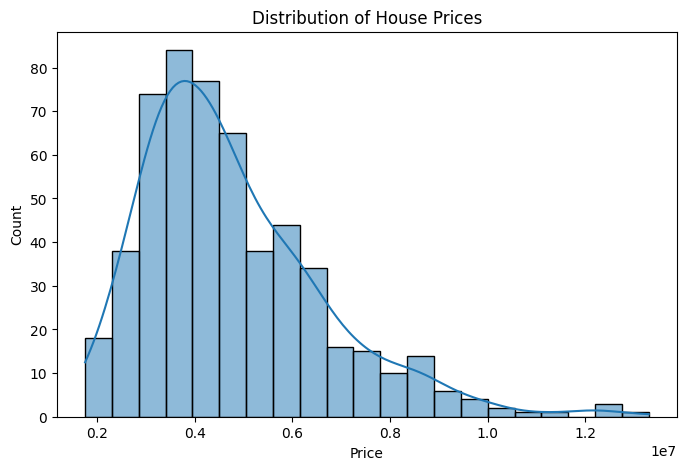

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

### Insight
Most houses are concentrated in a lower to medium price range, while a few houses have very high prices.

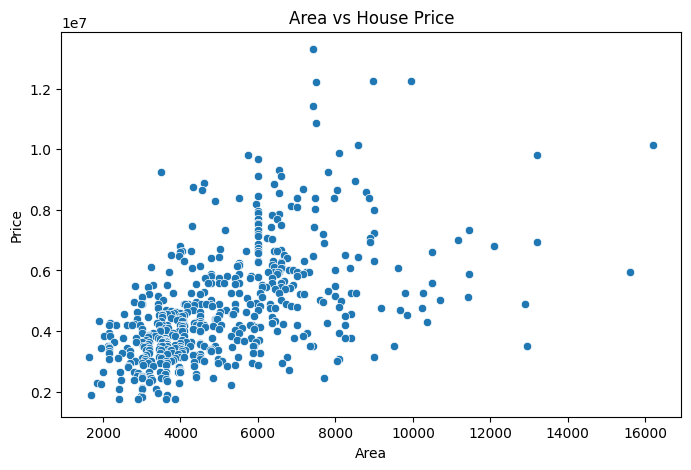

In [6]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="area", y="price", data=df)
plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

### Insight
House price generally increases as the area of the house increases.

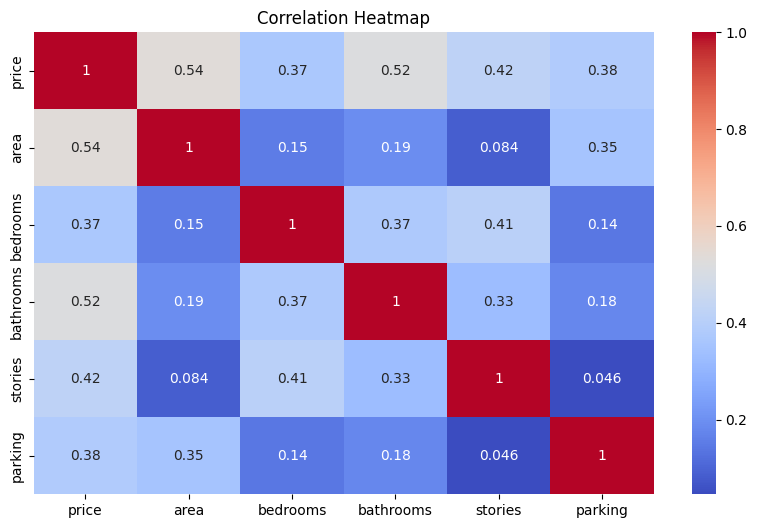

In [7]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Insight
Area shows a positive correlation with price, meaning larger houses generally have higher prices.

In [8]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [9]:
print(df_encoded.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')


In [10]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (545, 13)
Target shape: (545,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (436, 13)
X_test: (109, 13)
y_train: (436,)
y_test: (109,)


In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [13]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[5164653.90033967 7224722.29802166 3109863.24240338 4612075.32722559
 3294646.25725955 3532275.09556558 5611774.56836476 6368145.98732718
 2722856.95689985 2629405.61585782]


In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 970043.4039201636
Mean Squared Error: 1754318687330.6638
Root Mean Squared Error: 1324506.9600914386
R2 Score: 0.6529242642153184


### Model Evaluation
MAE, MSE, RMSE and R2 Score are used to evaluate the regression model. R2 Score shows how well the model explains the variation in house prices.

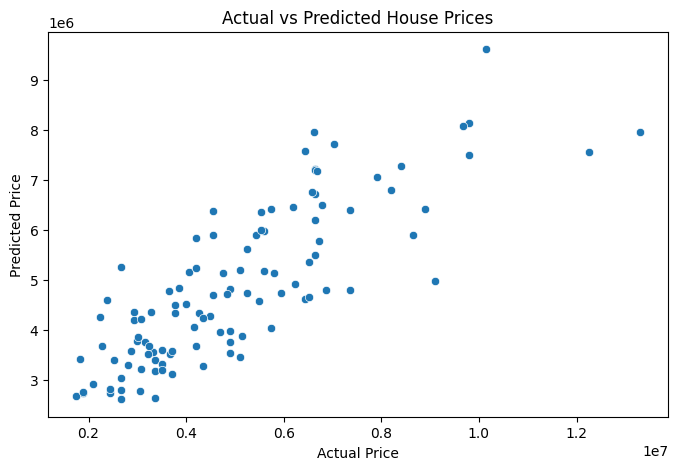

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

### Insight
If the predicted values are close to the actual values, the model is performing well.

In [16]:
sample = X_test.iloc[0:1]

predicted_price = model.predict(sample)

print("Predicted House Price:", predicted_price[0])
print("Actual House Price:", y_test.iloc[0])

Predicted House Price: 5164653.900339671
Actual House Price: 4060000


In [17]:
df_encoded.to_csv("cleaned_housing_data.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## Conclusion

In this project, a Linear Regression model was built to predict house prices.  
The dataset was cleaned, categorical features were converted into numerical form, and the data was split into training and testing sets.

The model was evaluated using MAE, MSE, RMSE and R2 Score.  
The analysis showed that features like area, bathrooms, stories and parking can influence house prices.

This project helped in understanding regression modeling, data preprocessing, visualization and model evaluation.